## ============================================================================

## E-COMMERCE FUNNEL ANALYTICS PROJECT
## NOTEBOOK: 02_EXPLORATORY_ANALYSIS

### PURPOSE:
### Explore user, session, product, category, price, and time behavior before
### building the session-level funnel analysis.

## ============================================================================

## Analysis objectives

1. Load the cleaned event-level dataset.
2. Review baseline users, sessions, products, and categories.
3. Compare event volumes across the main event types.
4. Review price and session activity distributions.
5. Analyze event volume by date and hour.
6. Identify the most active categories and products.

In [187]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.rcParams.update({
    "font.family": "Tahoma",
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

def format_chart(ax):
    ax.grid(
        axis="both",
        color="#E5E7EB",
        linewidth=0.8,
        alpha=0.8
    )

    sns.despine(
        ax=ax,
        top=True,
        right=True
    )
    return ax

general_color = "#6670A3"

## Load cleaned event data

The exploratory analysis uses the cleaned event-level dataset created during
data preparation. The raw source file remains unchanged.

In [185]:
events = pd.read_csv("../data/processed/events_clean.csv", parse_dates=["event_time", "event_date"])

print(f"Cleaned file: ../data/processed/events_clean.csv")
print(f"Rows loaded: {len(events)}")
events.head()

Cleaned file: ../data/processed/events_clean.csv
Rows loaded: 884312


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_hour,category_level_1,category_level_2,category_level_3
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,Unknown,31.90,1515915625519388267,LJuJVLEjPT,2020-09-24,11,electronics,telephone,Unknown
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020-09-24,11,computers,components,cooler
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,Unknown,Unknown,9.81,1515915625513238515,4TMArHtXQy,2020-09-24,11,Unknown,Unknown,Unknown
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020-09-24,11,computers,peripherals,printer
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,Unknown,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,2020-09-24,11,Unknown,Unknown,Unknown


## Baseline KPIs

I will review the main dimensions of the dataset before analyzing individual
event types or funnel stages.

In [ ]:
baseline_kpis = pd.DataFrame({
    "metric": [
        "Event records",
        "Unique users",
        "Unique sessions",
        "Unique products",
        "Unique category codes",
        "Average price",
        "Median price"
    ],
    "value": [
        len(events),
        events["user_id"].nunique(),
        events["user_session"].nunique(),
        events["product_id"].nunique(),
        events["category_code"].nunique(),
        events["price"].mean(),
        events["price"].median()
    ]
})

baseline_kpis

,metric,value
0,Event records,884312.00
1,Unique users,407237.00
2,Unique sessions,490398.00
3,Unique products,53452.00
4,Unique category codes,108.00
5,Average price,146.32
6,Median price,65.71


## Event volume by type

The event distribution provides the first view of the shopping journey.
These are event counts, not unique users or sessions.

In [12]:
event_order = ["view", "cart", "purchase"]
event_counts = (
    events["event_type"]
    .value_counts()
    .reindex(event_order)
    .rename_axis("event_type")
    .reset_index(name="event_count")
)
event_counts["event_percentage"] = event_counts["event_count"] / len(events) * 100
event_counts

,event_type,event_count,event_percentage
0,view,792943,89.67
1,cart,54026,6.11
2,purchase,37343,4.22


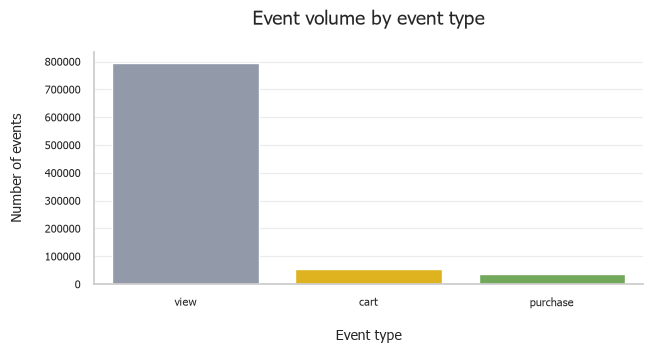

In [181]:
custom_palette = {
    "view": "#8E97AC",
    "cart": "#FFC400",
    "purchase": "#6CB54D"
}

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=event_counts,
    x="event_type",
    y="event_count",
    order=event_order,
    hue="event_type",
    hue_order=event_order,
    palette=custom_palette,
    legend=False,
    ax=ax
)

ax.set_title(
    "Event volume by event type",
    pad=20
)

ax.set_xlabel(
    "Event type",
    labelpad=15
)

ax.set_ylabel(
    "Number of events",
    labelpad=15
)

fig.tight_layout(pad=2)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Price distribution

I will review the price distribution to identify the typical price range and
potentially extreme values that may affect comparisons.

In [92]:
price_summary = events["price"].describe(
    percentiles=[0.25, 0.50,0.75, 0.90, 0.99]
)
price_summary

count   884312.00
mean       146.32
std        296.86
min          0.22
25%         26.46
50%         65.71
75%        190.54
90%        397.48
99%        889.98
max      64771.06
Name: price, dtype: float64

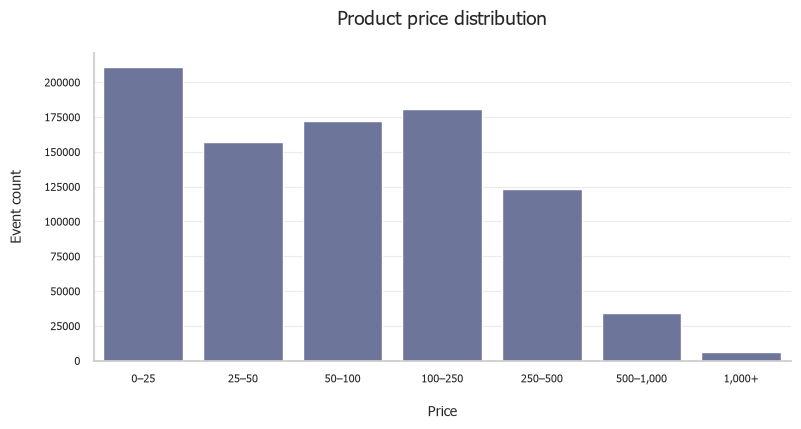

In [188]:
price_bins = [0, 25, 50, 100, 250, 500, 1000, float("inf")]

price_labels = ["0–25", "25–50", "50–100", "100–250", "250–500", "500–1,000", "1,000+"]

events["price_band"] = pd.cut(
    events["price"],
    bins=price_bins,
    labels=price_labels,
    right=False
)

price_band_counts = (
    events["price_band"]
    .value_counts(sort=False)
    .rename_axis("price_band")
    .reset_index(name="event_count")
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=price_band_counts,
    x="price_band",
    y ="event_count",
    color=general_color,
    ax=ax
)

ax.set_title(
    "Product price distribution",
    pad=20
)

ax.set_xlabel(
    "Price",
    labelpad=15
)

ax.set_ylabel(
    "Event count",
    labelpad=15
)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Session activity

I will review how many events are associated with each session. This prepares
the analysis for the session-level funnel without calculating conversion
metrics yet.

In [184]:
session_activity = (
    events.groupby(["user_id", "user_session"], as_index=False)
    .agg(
        user_id=("user_id", "first"),
        event_count=("event_type", "size"),
        unique_event_types=("event_type", "nunique"),
        session_start=("event_time", "min"),
        session_end=("event_time", "max")
    )
)
session_activity["duration_minutes"] = (
    session_activity["session_end"] - session_activity["session_start"]
).dt.total_seconds() / 60

session_activity[["event_count", "unique_event_types", "duration_minutes"]].describe()

,event_count,unique_event_types,duration_minutes
count,490633.00,490633.00,490633.00
mean,1.80,1.13,404.63
std,2.94,0.44,4784.63
min,1.00,1.00,0.00
25%,1.00,1.00,0.00
50%,1.00,1.00,0.00
75%,2.00,1.00,0.50
max,572.00,3.00,223240.28


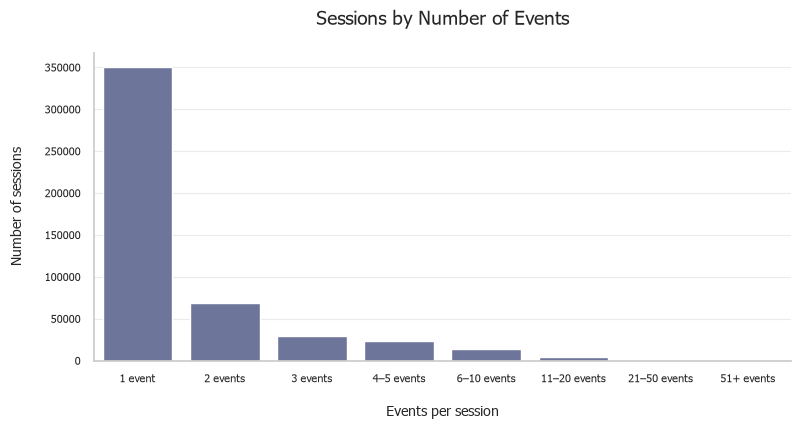

In [190]:
session_bins = [ 0, 1, 2, 3, 5, 10, 20, 50, float("inf")]

session_labels = [
    "1 event",
    "2 events",
    "3 events",
    "4–5 events",
    "6–10 events",
    "11–20 events",
    "21–50 events",
    "51+ events"
]

session_activity["event_band"] = pd.cut(
    session_activity["event_count"],
    bins=session_bins,
    labels=session_labels,
    right=True,
    include_lowest=True
)

session_event_bands = (
    session_activity["event_band"]
    .value_counts(sort=False)
    .rename_axis("event_band")
    .reset_index(name="session_count")
)

fig, ax = plt.subplots(figsize=(9, 4))

sns.barplot(
    data=session_event_bands,
    x="event_band",
    y="session_count",
    color=general_color,
    ax=ax
)

ax.set_title(
    "Sessions by Number of Events",
    pad=20
)

ax.set_xlabel(
    "Events per session",
    labelpad=15
)

ax.set_ylabel(
    "Number of sessions",
    labelpad=15
)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Event volume by date and hour

I will analyze when users are most active on the platform. The timestamps are
already represented in UTC.

In [130]:
daily_events = (
    events.groupby("event_date", as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
)

daily_events.head()

,event_date,event_count
0,2020-09-24,2262
1,2020-09-25,4239
2,2020-09-26,3462
3,2020-09-27,3849
4,2020-09-28,4712


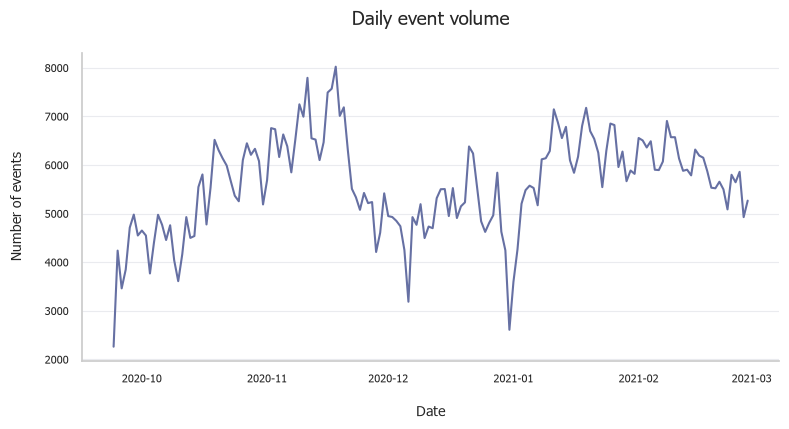

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.lineplot(
    data=daily_events, 
    x="event_date", 
    y="event_count",
    color=general_color,
    linewidth=1.5,
    ax=ax)

ax.set_title(
    "Daily event volume", 
    pad=20)

ax.set_xlabel(
    "Date", 
    labelpad=15)

ax.set_ylabel(
    "Number of events", 
    labelpad=15)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

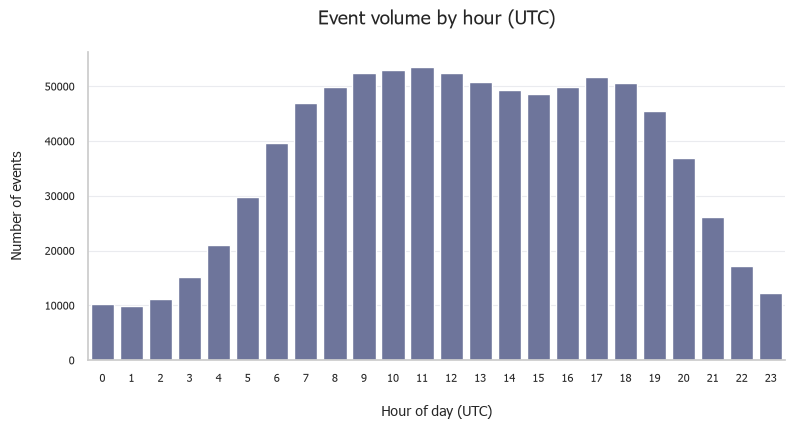

In [ ]:
hourly_events = (
    events.groupby("event_hour", as_index=False)
    .size()
    .rename(columns={"size": "event_count"})
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=hourly_events, 
    x="event_hour", 
    y="event_count", 
    color=general_color,
    ax=ax)

ax.set_title(
    "Event volume by hour (UTC)",
    pad=20)

ax.set_xlabel(
    "Hour of day (UTC)", 
    labelpad=15)

ax.set_ylabel(
    "Number of events", 
    labelpad=15)

format_chart(ax)
ax.grid(axis="x", visible=False)

plt.show()

## Category and product activity

I will identify the categories and products with the highest observed event
volume. These results will support the later business-question analysis.

In [163]:
category_summary = (
    events.groupby("category_level_1", as_index=False)
    .agg(
        event_count=("event_type", "size"),
        view_count=("event_type", lambda values: (values == "view").sum()),
        cart_count=("event_type", lambda values: (values == "cart").sum()),
        purchase_count=("event_type", lambda values: (values == "purchase").sum())
    )
    .sort_values("event_count", ascending=False)
)

category_summary.head(15)

,category_level_1,event_count,view_count,cart_count,purchase_count
5,computers,316660,272808,26982,16870
0,Unknown,236001,218028,10407,7566
8,electronics,170949,155125,9056,6768
14,stationery,42948,36796,3233,2919
3,appliances,41047,38938,1205,904
4,auto,35408,32858,1459,1091
6,construction,31035,28674,1362,999
9,furniture,3364,3093,156,115
7,country_yard,3137,3072,42,23
1,accessories,2075,1953,66,56


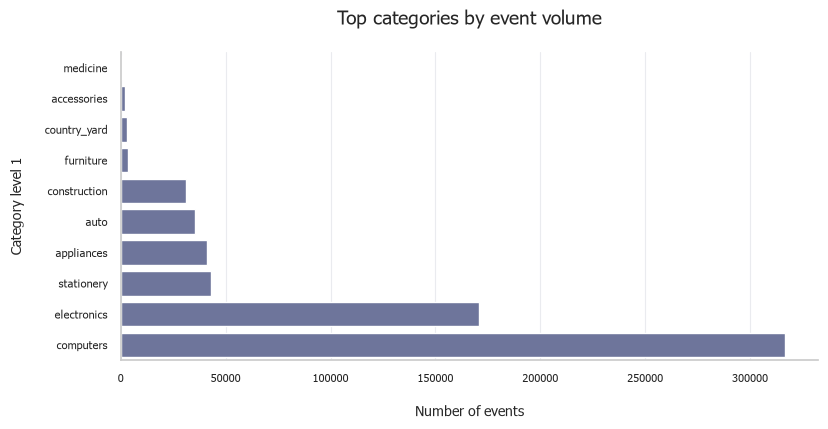

In [191]:
top_categories = (
    category_summary[category_summary["category_level_1"] != "Unknown"]
    .nlargest(10, "event_count")
    .sort_values("event_count")
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=top_categories, 
    x="event_count", 
    y="category_level_1", 
    color=general_color,
    ax=ax)

ax.set_title(
    "Top categories by event volume", 
    pad=20)

ax.set_xlabel(
    "Number of events", 
    labelpad=15)

ax.set_ylabel(
    "Category level 1", 
    labelpad=15)

format_chart(ax)
ax.grid(axis="y", visible=False)

plt.show()

In [ ]:
product_summary = (
    events.groupby("product_id", as_index=False)
    .agg(
        event_count=("event_type", "size"),
        view_count=("event_type", lambda values: (values == "view").sum()),
        cart_count=("event_type", lambda values: (values == "cart").sum()),
        purchase_count=("event_type", lambda values: (values == "purchase").sum()),
        average_price=("price", "mean")
    )
)

top_viewed_products = product_summary.nlargest(10, "view_count")
top_viewed_products

,product_id,event_count,view_count,cart_count,purchase_count,average_price
40709,1821813,14551,12793,1220,538,397.48
46705,3791351,6899,5715,761,423,204.29
50559,4099645,7086,5489,1033,564,292.83
39578,1785245,5117,4629,281,207,43.11
47812,3829355,5759,4552,664,543,32.22
19187,809948,4287,3830,270,187,64.48
41011,1830099,4198,3660,369,169,486.81
46769,3791509,3613,3150,314,149,466.52
52056,4154414,3707,3000,450,257,202.67
23539,893196,3911,2865,662,384,214.10
